# Seattle Rent Affordability Analysis

## Research question
How is the number of mixed-income apartments associated with median apartment rent per unit across Seattle census tracts from 2001 to 2025? Does the relationship differ for year-over-year rent growth, and how well can year, mixed-income count, and property count predict rent levels?

This notebook uses the supplied apartment-rent CSV only. The home-flips dataset mentioned in an earlier proposal is not included in this analysis.

## Part 1: Import libraries and load data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

data_path = Path('seattle_rent.csv')
if not data_path.exists():
    raise FileNotFoundError(
        'Place seattle_rent.csv in the same folder as this notebook.'
    )

df = pd.read_csv(data_path)
print('Data shape:', df.shape)
display(df.head())

Data shape: (4500, 18)


,OBJECTID,GEOID,Tract Label,Tract Name,Community Reporting Area Name,Community Reporting Area ID,Year,Tract Median Apartment Contract Rent per Square Foot,Tract Median Apartment Contract Rent per Unit,Year over Year Change in Rent per Square Foot,Year over Year Change in Rent per Unit,Cost Category,Year over Year Change in Rent Category,Mixed-Rate or Mixed-Income Apartment in Tract,Level of Concern,PROPERTIES,Shape__Area,Shape__Length
0,1,53033001201,12.01,Census Tract 12.01,Northgate/Maple Leaf,8.1,2001,1.51,1073,0.055944,0.051961,Low,Stable,1209,NaN,21,1.085186e+07,15899.773343
1,2,53033000404,4.04,Census Tract 4.04,Broadview/Bitter Lake,9.1,2001,1.29,1043,0.040323,0.041958,Low,Stable,454,NaN,7,6.791653e+06,12962.558413
2,3,53033004901,49.01,Census Tract 49.01,Fremont,11.1,2001,1.78,1059,0.047059,0.052684,Medium,Stable,977,NaN,106,5.350888e+06,9379.655767
3,4,53033003601,36.01,Census Tract 36.01,Green Lake,9.4,2001,2.10,1202,0.055276,0.055312,Medium,Stable,412,NaN,34,7.255879e+06,11894.288895
4,5,53033002800,28.00,Census Tract 28,Greenwood/Phinney Ridge,9.3,2001,1.59,998,0.052980,0.052743,Low,Stable,290,NaN,31,1.063715e+07,13201.311298


## Part 2: Data wrangling and validation

In [2]:
rename_map = {
    'Tract Median Apartment Contract Rent per Square Foot': 'rent_per_sqft',
    'Tract Median Apartment Contract Rent per Unit': 'rent_per_unit',
    'Year over Year Change in Rent per Square Foot': 'yoy_change_sqft',
    'Year over Year Change in Rent per Unit': 'yoy_change_unit',
    'Community Reporting Area Name': 'community',
    'Mixed-Rate or Mixed-Income Apartment in Tract': 'mixed_income_count',
    'Cost Category': 'cost_category',
    'PROPERTIES': 'property_count'
}
df = df.rename(columns=rename_map).copy()
required = ['GEOID', 'Year', 'rent_per_unit', 'rent_per_sqft',
            'yoy_change_unit', 'mixed_income_count', 'property_count', 'community']
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')
print('Year range:', df['Year'].min(), '-', df['Year'].max())
print('Unique tracts:', df['GEOID'].nunique())
print('Duplicate tract-year rows:', df.duplicated(['GEOID', 'Year']).sum())
print('Missing values in analysis fields:')
display(df[required].isna().sum().rename('missing').to_frame())

Year range: 2001 - 2025
Unique tracts: 180
Duplicate tract-year rows: 0
Missing values in analysis fields:


,missing
GEOID,0
Year,0
rent_per_unit,0
rent_per_sqft,0
yoy_change_unit,0
mixed_income_count,0
property_count,0
community,0


In [3]:
zero_rent_rows = (df['rent_per_unit'] <= 0).sum()
df = df.loc[df['rent_per_unit'] > 0].copy()
print('Rows removed because rent_per_unit <= 0:', zero_rent_rows)
print('Clean data shape:', df.shape)

Rows removed because rent_per_unit <= 0: 569
Clean data shape: (3931, 18)


## Part 3: Descriptive statistics and exploratory analysis

In [4]:
summary = df[['rent_per_unit', 'rent_per_sqft', 'mixed_income_count', 'yoy_change_unit']].describe().round(3)
display(summary)

,rent_per_unit,rent_per_sqft,mixed_income_count,yoy_change_unit
count,3931.000,3931.000,3931.000,3931.000
mean,1486.239,2.249,636.806,0.021
std,432.740,0.630,539.844,0.040
min,549.000,0.740,52.000,-0.221
25%,1185.000,1.810,216.000,0.008
50%,1432.000,2.230,468.000,0.021
75%,1722.000,2.700,923.500,0.041
max,3674.000,4.200,3708.000,0.367


### 3.1 Rent distribution

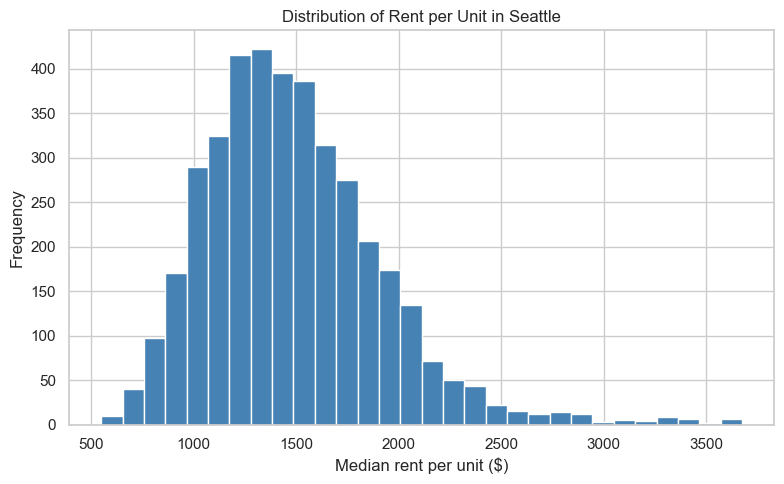

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df['rent_per_unit'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Median rent per unit ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Rent per Unit in Seattle')
plt.tight_layout()
plt.show()

### 3.2 Rent trend over time

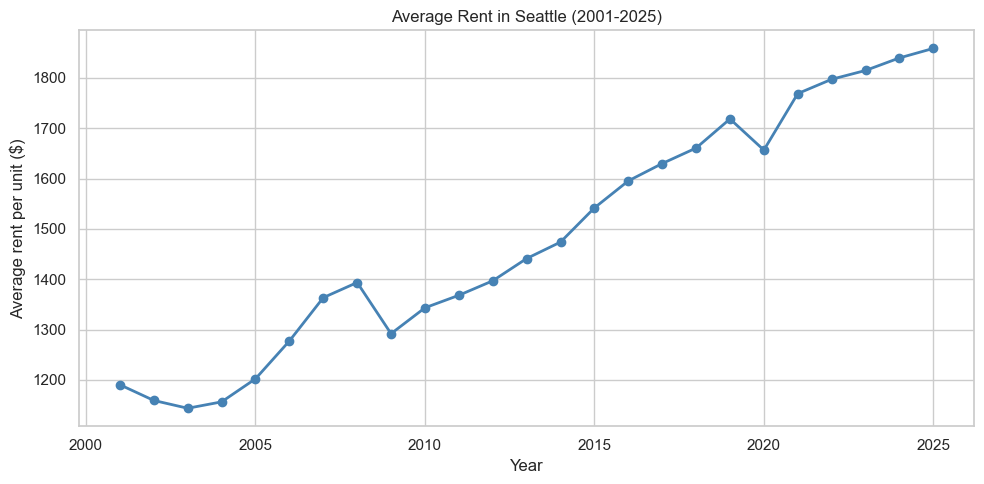

In [6]:
yearly_avg = df.groupby('Year', as_index=True)['rent_per_unit'].mean()
plt.figure(figsize=(10, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average rent per unit ($)')
plt.title('Average Rent in Seattle (2001-2025)')
plt.tight_layout()
plt.show()

### 3.3 Community comparison

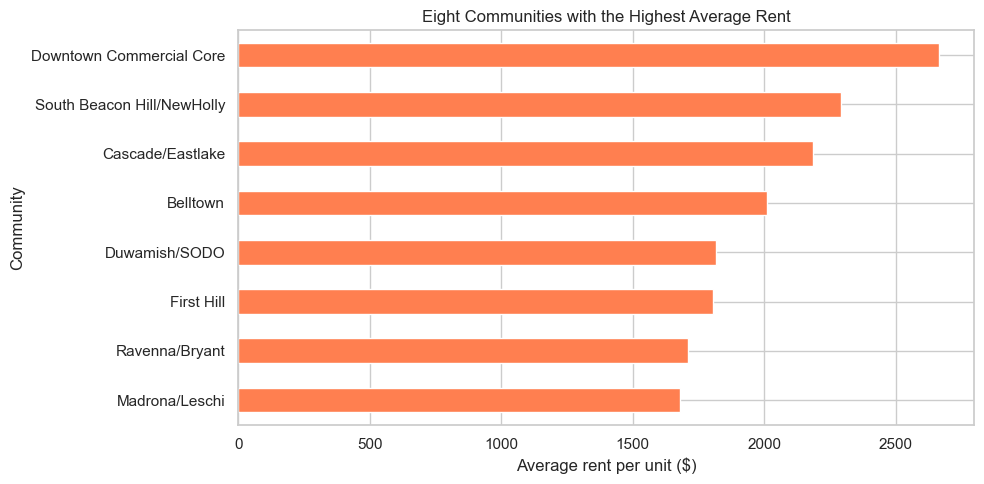

In [7]:
community_rent = df.groupby('community')['rent_per_unit'].mean().sort_values(ascending=False)
top8 = community_rent.head(8)
plt.figure(figsize=(10, 5))
top8.sort_values().plot(kind='barh', color='coral')
plt.xlabel('Average rent per unit ($)')
plt.ylabel('Community')
plt.title('Eight Communities with the Highest Average Rent')
plt.tight_layout()
plt.show()

### 3.4 Mixed-income apartments and rent

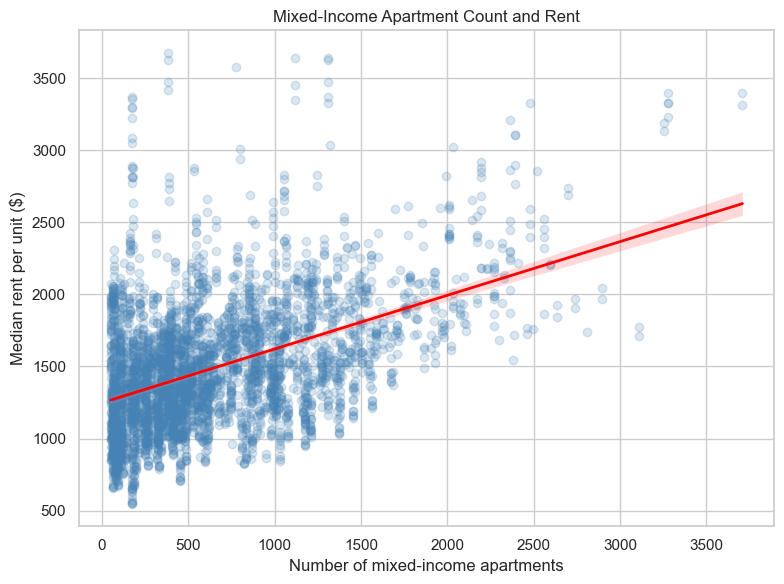

In [8]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='mixed_income_count', y='rent_per_unit', data=df,
    scatter_kws={'alpha': 0.2, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.xlabel('Number of mixed-income apartments')
plt.ylabel('Median rent per unit ($)')
plt.title('Mixed-Income Apartment Count and Rent')
plt.tight_layout()
plt.show()

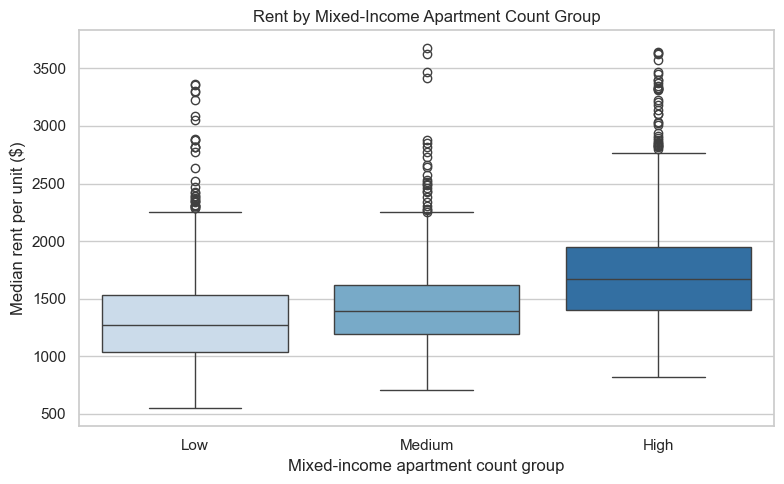

In [9]:
df['mi_group'] = pd.qcut(
    df['mixed_income_count'], q=3, labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='mi_group', y='rent_per_unit', data=df,
    hue='mi_group', palette='Blues', legend=False
)
plt.xlabel('Mixed-income apartment count group')
plt.ylabel('Median rent per unit ($)')
plt.title('Rent by Mixed-Income Apartment Count Group')
plt.tight_layout()
plt.show()

In [10]:
print('Correlation between mixed-income count and rent:',
      round(df['mixed_income_count'].corr(df['rent_per_unit']), 4))
print('Correlation between mixed-income count and rent growth:',
      round(df['mixed_income_count'].corr(df['yoy_change_unit']), 4))

Correlation between mixed-income count and rent: 0.4643
Correlation between mixed-income count and rent growth: -0.0136


### 3.5 Correlation heatmap

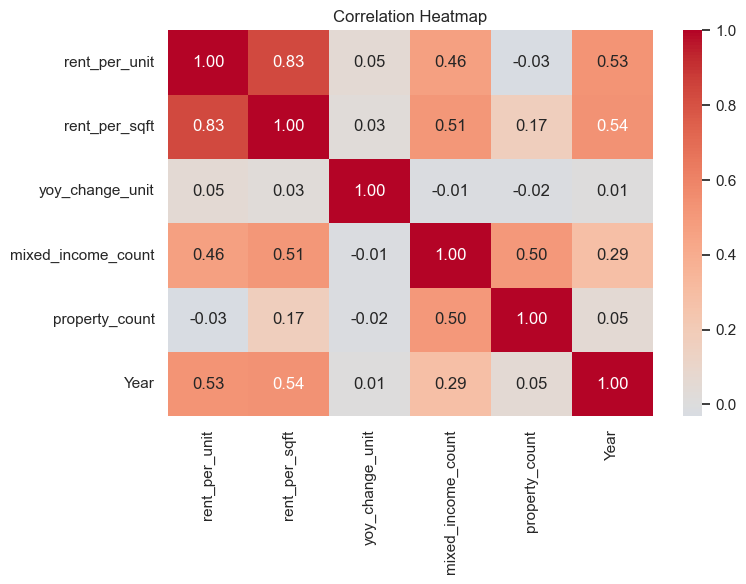

In [11]:
numeric_cols = ['rent_per_unit', 'rent_per_sqft', 'yoy_change_unit',
                'mixed_income_count', 'property_count', 'Year']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Part 4: Model development and evaluation

The random split is retained as a reproducible benchmark for the assignment. Because the data contain repeated observations for the same tract, a time-aware sensitivity check is also reported below. R² and mean squared error (MSE) are evaluated on held-out data.

In [12]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

features = ['Year', 'mixed_income_count', 'property_count']
X = df[features]
y = df['rent_per_unit']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)
print('Random split - train:', len(X_train), 'test:', len(X_test))

Random split - train: 3144 test: 787


In [13]:
models = {
    'Linear regression': LinearRegression(),
    'Polynomial regression (degree 2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scale', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge regression (degree 2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scale', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ])
}

random_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    random_results.append({
        'model': name,
        'R2': r2_score(y_test, pred),
        'MSE': mean_squared_error(y_test, pred)
    })

random_results_df = pd.DataFrame(random_results).round({'R2': 4, 'MSE': 2})
display(random_results_df)

,model,R2,MSE
0,Linear regression,0.4220,108294.43
1,Polynomial regression (degree 2),0.4537,102358.00
2,Ridge regression (degree 2),0.4445,104076.99


### 4.1 Time-aware sensitivity check

In [14]:
cutoff_year = 2020
train_mask = df['Year'] <= cutoff_year
test_mask = df['Year'] > cutoff_year
X_train_time, X_test_time = X.loc[train_mask], X.loc[test_mask]
y_train_time, y_test_time = y.loc[train_mask], y.loc[test_mask]

time_results = []
for name, model in models.items():
    model.fit(X_train_time, y_train_time)
    pred = model.predict(X_test_time)
    time_results.append({
        'model': name,
        'R2': r2_score(y_test_time, pred),
        'MSE': mean_squared_error(y_test_time, pred)
    })

time_results_df = pd.DataFrame(time_results).round({'R2': 4, 'MSE': 2})
print(f'Time split: train through {cutoff_year}; test after {cutoff_year}')
display(time_results_df)

Time split: train through 2020; test after 2020


,model,R2,MSE
0,Linear regression,0.4369,92901.18
1,Polynomial regression (degree 2),0.4787,86008.32
2,Ridge regression (degree 2),0.4744,86716.00


## Part 5: Interpretation and limitations

A positive correlation between mixed-income apartment count and rent level does not show that mixed-income housing causes higher rent. It may reflect location, tract size, property composition, or other omitted variables. The model is predictive rather than causal. The repeated-tract structure also means that a random split can be optimistic; the time-aware results provide a more realistic sensitivity check for forecasting later years. Median contract rent is a market measure, not a complete measure of household affordability.

## Part 6: Conclusion template

After reviewing the completed tables and figures, summarize: (1) the time trend in average rent, (2) differences across communities, (3) the mixed-income association with rent level and rent growth, (4) which model performs best under each split, and (5) the limits of causal interpretation.